In [56]:
import os
print(os.listdir("E:/CLV/"))


['Online Retail.xlsx']


In [57]:
import pandas as pd
import numpy as np

# Correct path - file is directly in E:/CLV/
file_path = "E:/CLV/Online Retail.xlsx"
df = pd.read_excel(file_path)

# Create total spend per line item
df["TotalSpend"] = df["Quantity"] * df["UnitPrice"]

# Remove cancelled orders (negative quantity) and zero/negative spend
df = df[(df["TotalSpend"] > 0) & (~df["CustomerID"].isna())]

# Convert invoice date to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Cleaned dataset shape:", df.shape)
print("Date range:", df["InvoiceDate"].min(), "→", df["InvoiceDate"].max())
print("Unique customers:", df["CustomerID"].nunique())


Cleaned dataset shape: (397884, 9)
Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique customers: 4338


In [58]:
cutoff = pd.to_datetime("2011-09-01")

# History window (before cutoff) for RFM
hist_df = df[df["InvoiceDate"] < cutoff]
rfm = hist_df.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", lambda x: (cutoff - x.max()).days),
    Frequency = ("InvoiceNo", "nunique"),
    Monetary = ("TotalSpend", "sum")
).reset_index()

# Future window (after cutoff) for target future_clv
fut_df = df[df["InvoiceDate"] >= cutoff]
future_clv = fut_df.groupby("CustomerID")["TotalSpend"].sum().reset_index()
future_clv.columns = ["CustomerID", "future_clv"]

# Merge RFM features with future spend
model_df = rfm.merge(future_clv, on="CustomerID", how="left")
model_df["future_clv"] = model_df["future_clv"].fillna(0)

# Churn flag: 1 = no purchase in future window (churned), 0 = bought again (retained)
model_df["churn_flag"] = (model_df["future_clv"] == 0).astype(int)

print("Final customer dataset shape:", model_df.shape)
print("\nfuture_clv stats:")
print(model_df["future_clv"].describe())
print("\nChurn distribution:")
print(model_df["churn_flag"].value_counts())


Final customer dataset shape: (3317, 6)

future_clv stats:
count      3317.000000
mean        914.249259
std        5187.731842
min           0.000000
25%           0.000000
50%         202.020000
75%         748.170000
max      168469.600000
Name: future_clv, dtype: float64

Churn distribution:
churn_flag
0    1952
1    1365
Name: count, dtype: int64


In [59]:
from sklearn.model_selection import train_test_split

X = model_df[["Recency", "Frequency", "Monetary"]]
y_clv = model_df["future_clv"]
y_churn = model_df["churn_flag"]

X_train, X_test, y_clv_train, y_clv_test, y_churn_train, y_churn_test = train_test_split(
    X, y_clv, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train churn distribution:\n{y_churn_train.value_counts()}")
print(f"Test churn distribution:\n{y_churn_test.value_counts()}")


X_train: (2653, 3), X_test: (664, 3)
Train churn distribution:
churn_flag
0    1561
1    1092
Name: count, dtype: int64
Test churn distribution:
churn_flag
0    391
1    273
Name: count, dtype: int64


In [60]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

clv_model = xgb.XGBRegressor(random_state=42, n_estimators=100, objective="reg:squarederror")
clv_model.fit(X_train, y_clv_train)
y_pred_clv = clv_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_clv_test, y_pred_clv))
r2 = r2_score(y_clv_test, y_pred_clv)

print(f"CLV Regression RMSE: {rmse:.2f}")
print(f"CLV Regression R²:   {r2:.4f}")


CLV Regression RMSE: 10913.09
CLV Regression R²:   -1.2773


In [61]:
from sklearn.metrics import accuracy_score, classification_report

churn_model = xgb.XGBClassifier(random_state=42, n_estimators=100, objective="binary:logistic")
churn_model.fit(X_train, y_churn_train)
y_pred_churn = churn_model.predict(X_test)

print("Churn Prediction Accuracy:", accuracy_score(y_churn_test, y_pred_churn))
print("\nClassification Report:\n")
print(classification_report(y_churn_test, y_pred_churn))


Churn Prediction Accuracy: 0.6400602409638554

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.68      0.69       391
           1       0.56      0.58      0.57       273

    accuracy                           0.64       664
   macro avg       0.63      0.63      0.63       664
weighted avg       0.64      0.64      0.64       664



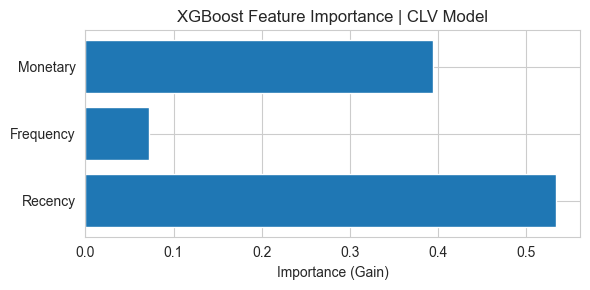

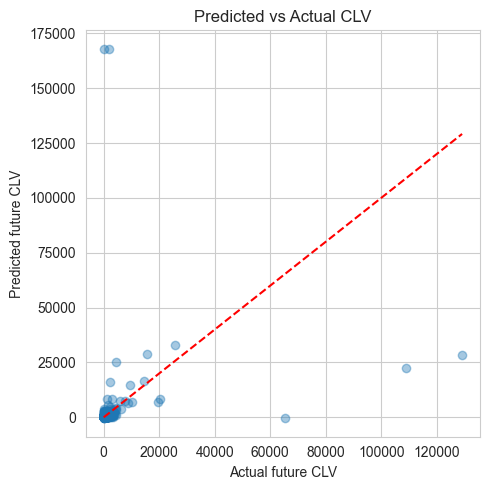

In [62]:
import matplotlib.pyplot as plt

# Feature importance plot
plt.figure(figsize=(6,3))
plt.barh(X.columns, clv_model.feature_importances_)
plt.xlabel("Importance (Gain)")
plt.title("XGBoost Feature Importance | CLV Model")
plt.tight_layout()
plt.show()

# Predicted vs Actual CLV scatter plot
plt.figure(figsize=(5,5))
plt.scatter(y_clv_test, y_pred_clv, alpha=0.4)
lim = [y_clv_test.min(), y_clv_test.max()]
plt.plot(lim, lim, "r--")
plt.xlabel("Actual future CLV")
plt.ylabel("Predicted future CLV")
plt.title("Predicted vs Actual CLV")
plt.tight_layout()
plt.show()


In [63]:
# Log transform target (add +1 to avoid log(0))
y_clv_train_log = np.log1p(y_clv_train)
y_clv_test_log  = np.log1p(y_clv_test)

clv_log_model = xgb.XGBRegressor(random_state=42, n_estimators=100, objective="reg:squarederror")
clv_log_model.fit(X_train, y_clv_train_log)

y_pred_log = clv_log_model.predict(X_test)
# Convert predictions back to original currency scale
y_pred_clv_corrected = np.expm1(y_pred_log)

rmse_corrected = np.sqrt(mean_squared_error(y_clv_test, y_pred_clv_corrected))
r2_corrected = r2_score(y_clv_test, y_pred_clv_corrected)

print(f"Log-transformed CLV RMSE: {rmse_corrected:.2f}")
print(f"Log-transformed CLV R²:   {r2_corrected:.4f}")


Log-transformed CLV RMSE: 6114.30
Log-transformed CLV R²:   0.2851


Churn Model AUC-ROC: 0.6894


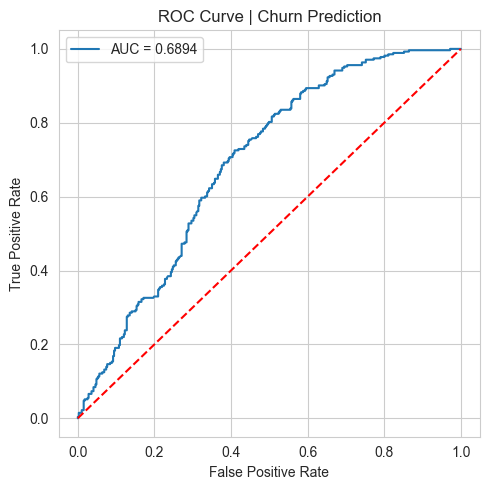

In [64]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability scores for class 1 (churn)
y_pred_churn_prob = churn_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_churn_test, y_pred_churn_prob)

print(f"Churn Model AUC-ROC: {auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_churn_test, y_pred_churn_prob)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve | Churn Prediction")
plt.legend()
plt.tight_layout()
plt.show()


In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2,3,4],
    "learning_rate": [0.01,0.05,0.1],
    "n_estimators": [80,100,120]
}

grid_search = GridSearchCV(estimator=xgb.XGBClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring="roc_auc",
                           cv=5)
grid_search.fit(X_train, y_churn_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation AUC:", grid_search.best_score_)


Best parameters: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}
Best cross-validation AUC: 0.7375440705701958


In [66]:
# Optimized churn model
best_churn_model = xgb.XGBClassifier(
    learning_rate=0.01,
    max_depth=2,
    n_estimators=100,
    random_state=42
)
best_churn_model.fit(X_train, y_churn_train)

y_pred_opt = best_churn_model.predict(X_test)
y_pred_opt_prob = best_churn_model.predict_proba(X_test)[:,1]

auc_opt = roc_auc_score(y_churn_test, y_pred_opt_prob)
acc_opt = accuracy_score(y_churn_test, y_pred_opt)

print(f"Tuned Churn Model Test AUC: {auc_opt:.4f}")
print(f"Tuned Churn Model Test Accuracy: {acc_opt:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_churn_test, y_pred_opt))


Tuned Churn Model Test AUC: 0.7391
Tuned Churn Model Test Accuracy: 0.6702

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.83      0.75       391
           1       0.65      0.44      0.52       273

    accuracy                           0.67       664
   macro avg       0.66      0.63      0.63       664
weighted avg       0.67      0.67      0.65       664



In [67]:
# Compute extra customer features from raw transaction data
customer_stats = df.groupby("CustomerID").agg(
    AvgOrderValue = ("TotalSpend", "mean"),
    AvgItemsPerOrder = ("Quantity", "mean"),
    UniqueProducts = ("StockCode", "nunique")
).reset_index()

# Merge new features into our model dataframe
model_df_extended = model_df.merge(customer_stats, on="CustomerID", how="left")

# New feature list
feature_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "AvgItemsPerOrder", "UniqueProducts"]
X_new = model_df_extended[feature_cols]
y_clv = model_df_extended["future_clv"]
y_churn = model_df_extended["churn_flag"]

# Re-split with same random state to keep consistency
from sklearn.model_selection import train_test_split
X_train_new, X_test_new, y_clv_train, y_clv_test, y_churn_train, y_churn_test = train_test_split(
    X_new, y_clv, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

print("New feature set:", feature_cols)
print(f"X_train_new shape: {X_train_new.shape}")


New feature set: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgItemsPerOrder', 'UniqueProducts']
X_train_new shape: (2653, 6)


In [68]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Log transform target
y_clv_train_log = np.log1p(y_clv_train)
y_clv_test_log = np.log1p(y_clv_test)

param_grid_reg = {
    "max_depth": [2,3],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [100,150]
}

grid_reg = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, objective="reg:squarederror"),
    param_grid=param_grid_reg,
    cv=5,
    scoring="r2"
)

grid_reg.fit(X_train_new, y_clv_train_log)
print("Best params for regression:", grid_reg.best_params_)
print("Best CV R² (log target):", grid_reg.best_score_)

# Test on holdout set
best_reg_model = grid_reg.best_estimator_
y_pred_log = best_reg_model.predict(X_test_new)
y_pred_corrected = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_clv_test, y_pred_corrected))
r2 = r2_score(y_clv_test, y_pred_corrected)

print(f"\nFinal Test RMSE: {rmse:.2f}")
print(f"Final Test R²: {r2:.4f}")


Best params for regression: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
Best CV R² (log target): 0.5998525826215475

Final Test RMSE: 5961.39
Final Test R²: 0.3204


In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

param_grid_churn = {
    "max_depth": [2,3],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [100,150]
}

grid_churn = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42),
    param_grid=param_grid_churn,
    scoring="roc_auc",
    cv=5
)

grid_churn.fit(X_train_new, y_churn_train)
print("Best churn parameters:", grid_churn.best_params_)
print("Best cross-validation AUC:", grid_churn.best_score_)

# Evaluate on test set
best_churn_extended = grid_churn.best_estimator_
y_pred_churn_ext = best_churn_extended.predict(X_test_new)
y_pred_churn_ext_prob = best_churn_extended.predict_proba(X_test_new)[:,1]

test_auc_ext = roc_auc_score(y_churn_test, y_pred_churn_ext_prob)
test_acc_ext = accuracy_score(y_churn_test, y_pred_churn_ext)

print(f"\nTest AUC: {test_auc_ext:.4f}")
print(f"Test Accuracy: {test_acc_ext:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_churn_test, y_pred_churn_ext))


Best churn parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
Best cross-validation AUC: 0.9108285765363713

Test AUC: 0.9202
Test Accuracy: 0.8404

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       391
           1       0.81      0.81      0.81       273

    accuracy                           0.84       664
   macro avg       0.84      0.84      0.84       664
weighted avg       0.84      0.84      0.84       664



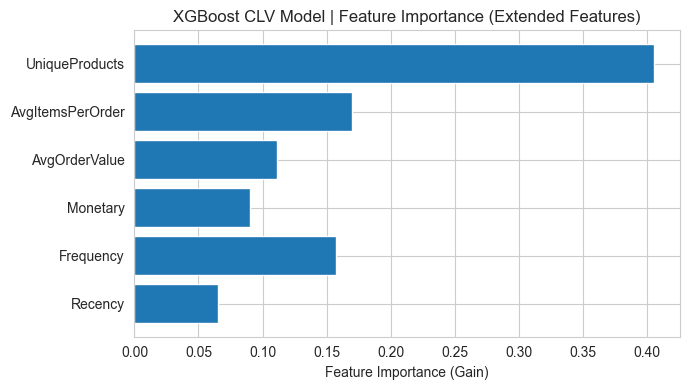

In [70]:
import matplotlib.pyplot as plt

feature_names = X_train_new.columns
importance = best_reg_model.feature_importances_

plt.figure(figsize=(7,4))
plt.barh(feature_names, importance)
plt.xlabel("Feature Importance (Gain)")
plt.title("XGBoost CLV Model | Feature Importance (Extended Features)")
plt.tight_layout()
plt.show()


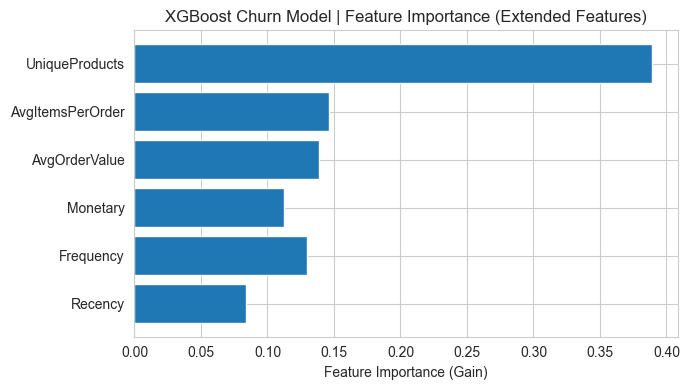

In [71]:
import matplotlib.pyplot as plt

feature_names = X_train_new.columns
importance_churn = best_churn_extended.feature_importances_

plt.figure(figsize=(7,4))
plt.barh(feature_names, importance_churn)
plt.xlabel("Feature Importance (Gain)")
plt.title("XGBoost Churn Model | Feature Importance (Extended Features)")
plt.tight_layout()
plt.show()
